In [2]:
import pandas as pd

df = pd.read_csv('cleaned_movies.csv')

df.head(3)

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,status,tagline,title,vote_average,vote_count,cast,crew,director,year,profit
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,2009.0,2550965087
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski,2007.0,661000000
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes,2015.0,635674609


In [3]:
df['ROI'] = (df['revenue'] - df['budget']) / df['budget']

df['is_profitable'] = df['ROI'].apply(lambda x: 1 if x > 0 else 0)

genre_dummies = df['genres'].fillna('').str.get_dummies(sep=' ')
df = pd.concat([df, genre_dummies], axis=1)

print(df['is_profitable'].value_counts())

is_profitable
1    2326
0    1313
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

feature_columns = ['budget', 'year', 'Action', 'Comedy', 'Drama', 'Thriller']
X = df[feature_columns].fillna(0)

y = df['is_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split")

Data successfully split


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 58.52%


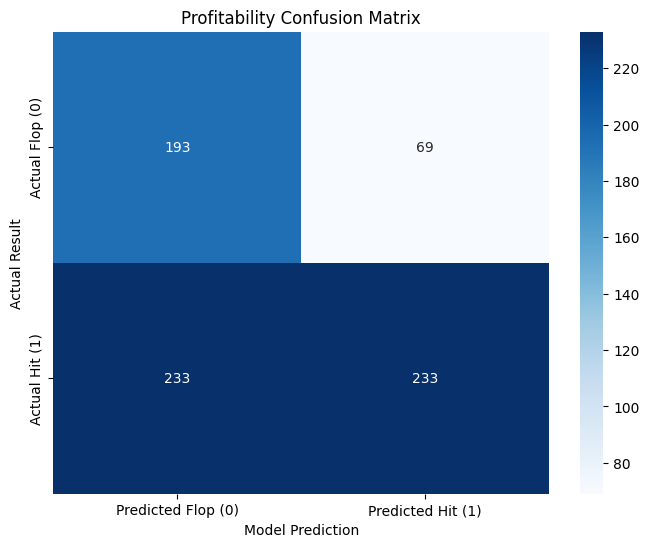

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Flop (0)', 'Predicted Hit (1)'],
            yticklabels=['Actual Flop (0)', 'Actual Hit (1)'])

plt.title('Profitability Confusion Matrix')
plt.ylabel('Actual Result')
plt.xlabel('Model Prediction')
plt.show()